In [85]:
import pandas as pd 
import numpy as np 
import matplotlib 
from pathlib import Path
import seaborn as sns

# Model Selection and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [86]:
data_path = Path('../data/preprocessed_pokemon_data.csv')
pkmn_df = pd.read_csv(data_path)
seed = 42

In [87]:
target = ['tier']
X = pkmn_df.drop(columns=[t for t in target])
y = pkmn_df[target]

# 80% train 20% test, stratify is to make sure the tier distribution is more even in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)

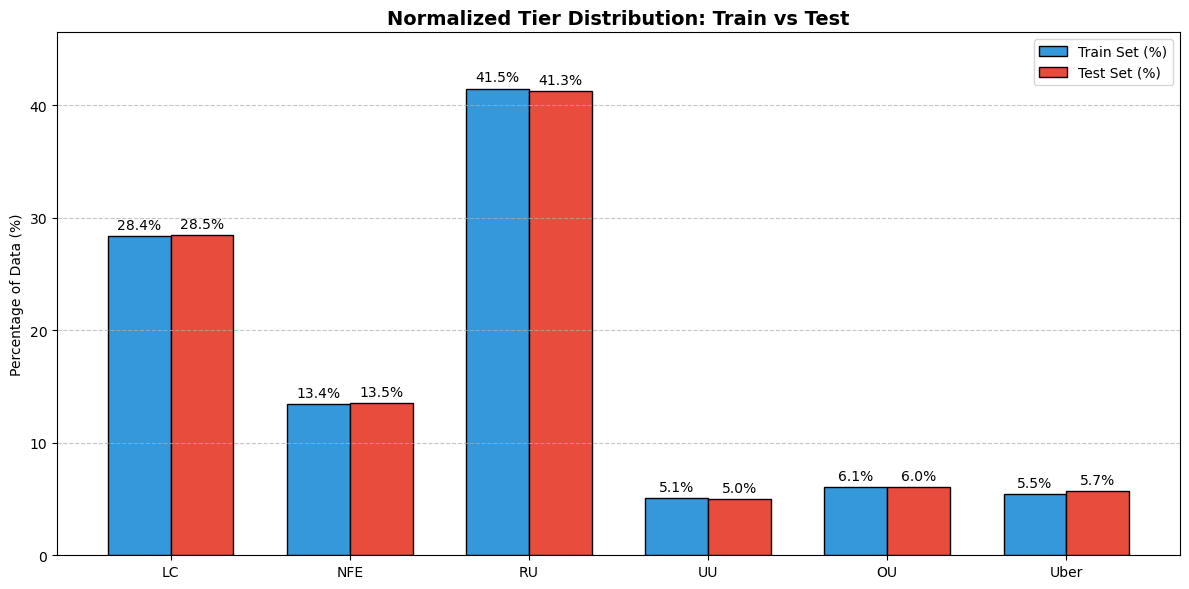

In [88]:
# graph train/test set tier frequency
tier_labels = ['LC', 'NFE', 'RU', 'UU', 'OU', 'Uber']

train_freq = (pd.Series(np.array(y_train).ravel()).value_counts(normalize=True) * 100).reindex(range(len(tier_labels)), fill_value=0)
test_freq = (pd.Series(np.array(y_test).ravel()).value_counts(normalize=True) * 100).reindex(range(len(tier_labels)), fill_value=0)

x = np.arange(len(tier_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, train_freq, width, label='Train Set (%)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, test_freq, width, label='Test Set (%)', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Percentage of Data (%)')
ax.set_title('Normalized Tier Distribution: Train vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.set_ylim(0, max(train_freq.max(), test_freq.max()) + 5)
ax.legend()

ax.bar_label(rects1, fmt='%.1f%%', padding=3)
ax.bar_label(rects2, fmt='%.1f%%', padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

In [89]:
'''
NOTE: objective: multi-softclass essentially tells the model it is doing a classification problem
given multiple classes like OU, UU, etc. choose the most fitting one and output; softmax converts tier scores->probabilities

'''

tier_model = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.1,
    max_depth=6,
    num_class=len(np.unique(y))
)

tier_model.fit(X_train, y_train)
predictions = tier_model.predict(X_test)


print(classification_report(y_test, predictions, zero_division=0))

mae = mean_absolute_error(y_test, predictions)


              precision    recall  f1-score   support

           0       0.94      0.99      0.96        80
           1       0.86      0.66      0.75        38
           2       0.80      0.91      0.85       116
           3       0.00      0.00      0.00        14
           4       0.47      0.41      0.44        17
           5       0.73      0.69      0.71        16

    accuracy                           0.81       281
   macro avg       0.63      0.61      0.62       281
weighted avg       0.78      0.81      0.79       281



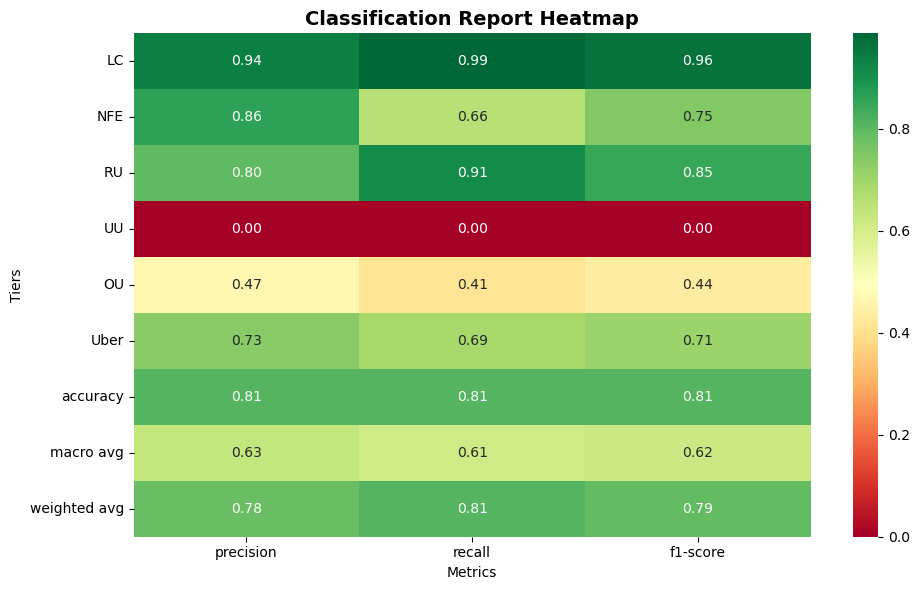

In [90]:
report_dict = classification_report(y_test, predictions, target_names=tier_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax)

ax.set_title('Classification Report Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrics')
ax.set_ylabel('Tiers')

plt.tight_layout()
plt.show()

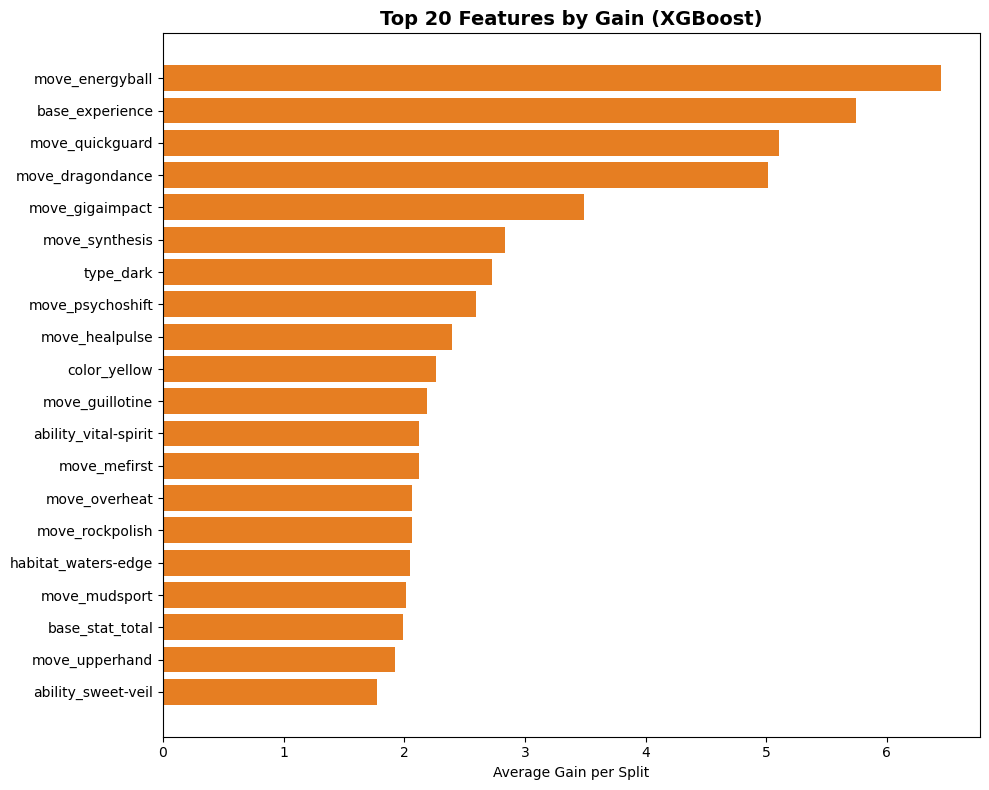

In [91]:
# Get importance dictionary (default is 'gain')
importance_dict = tier_model.get_booster().get_score(importance_type='gain')

# Convert to DataFrame and sort
feature_importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'].head(20), feature_importance_df['importance'].head(20), color='#e67e22')
plt.gca().invert_yaxis()
plt.title('Top 20 Features by Gain (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Average Gain per Split')
plt.tight_layout()
plt.show()

In [92]:
tier_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    max_features='sqrt',
    random_state=seed,
    class_weight='balanced_subsample' # chose because some tiers have very few mons
)

tier_rf.fit(X_train, y_train.values.ravel())
rf_predictions = tier_rf.predict(X_test)

# evaluate
print("--- Random Forest Tier Prediction Results ---")
print(classification_report(y_test, rf_predictions, zero_division=0))

--- Random Forest Tier Prediction Results ---
              precision    recall  f1-score   support

           0       0.91      0.99      0.95        80
           1       0.95      0.50      0.66        38
           2       0.71      0.95      0.81       116
           3       0.50      0.07      0.12        14
           4       0.67      0.12      0.20        17
           5       0.71      0.62      0.67        16

    accuracy                           0.79       281
   macro avg       0.74      0.54      0.57       281
weighted avg       0.79      0.79      0.75       281



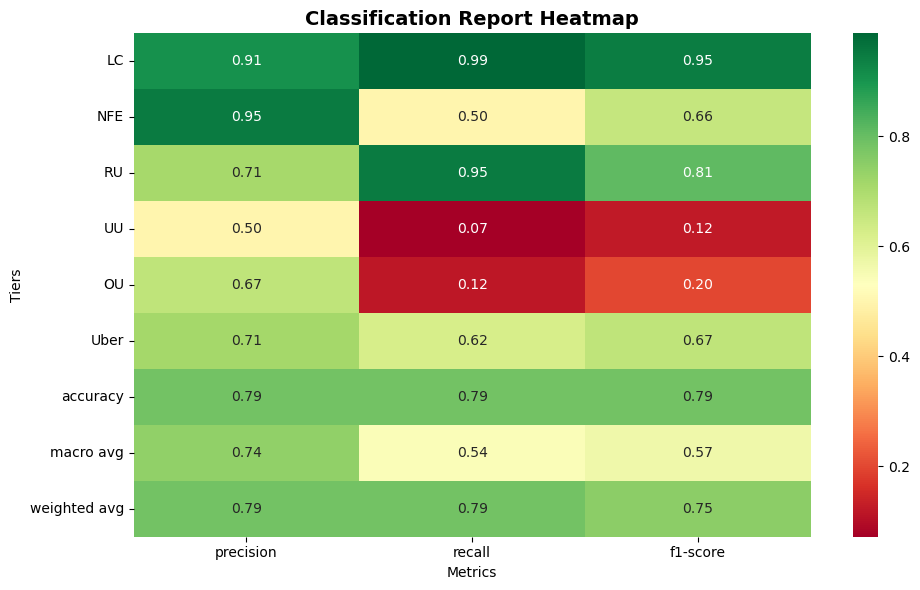

In [93]:
report_dict = classification_report(y_test, rf_predictions, target_names=tier_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax)

ax.set_title('Classification Report Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrics')
ax.set_ylabel('Tiers')

plt.tight_layout()
plt.show()

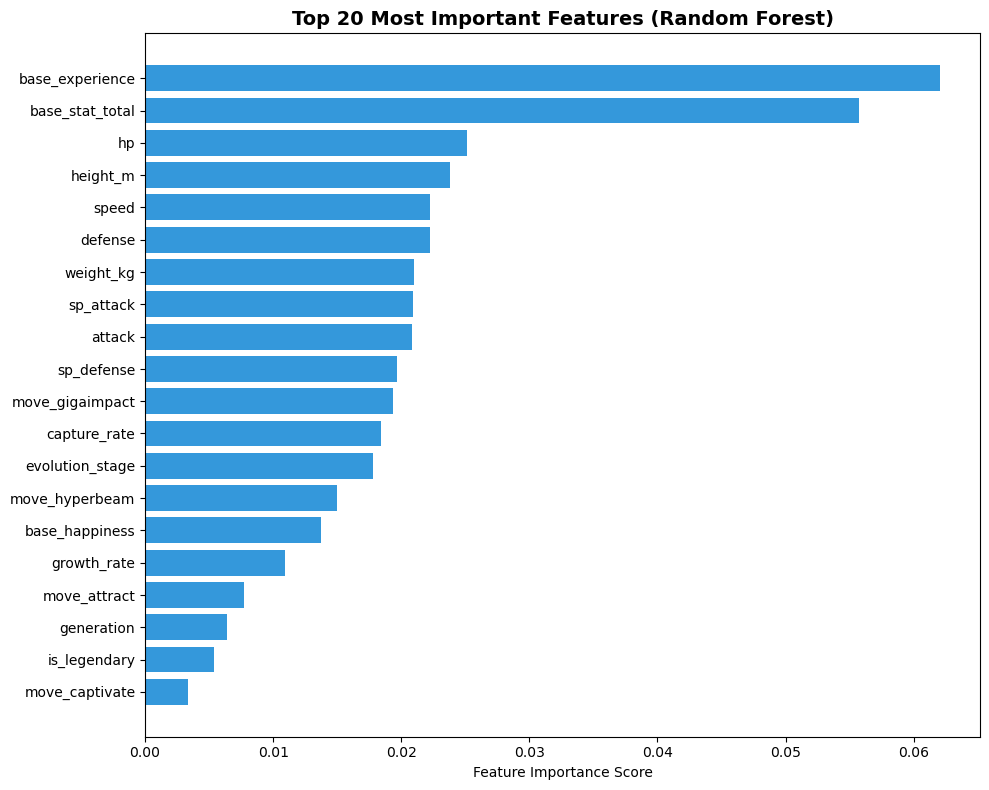

In [94]:
importances = tier_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'].head(20), feature_importance_df['importance'].head(20), color='#3498db')
plt.gca().invert_yaxis()
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

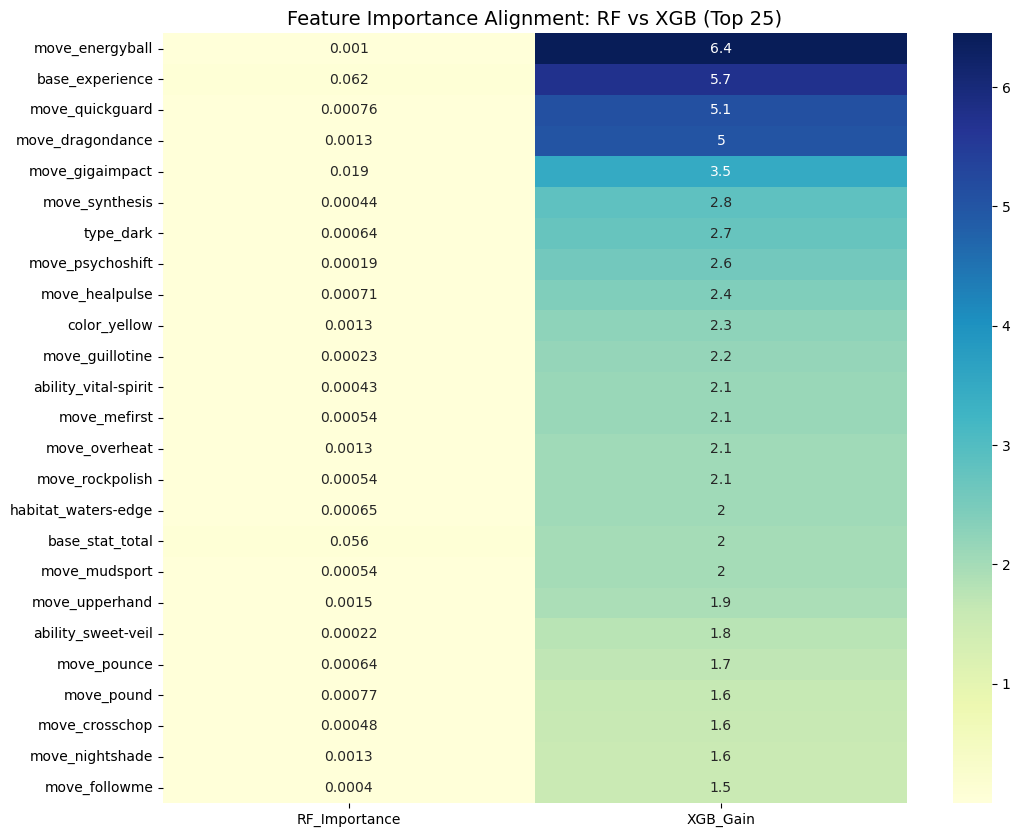

Correlation between RF and XGB importance weights: 0.3097268945460506


In [97]:
# 1. Extract Importance from RF
rf_imp = pd.Series(tier_rf.feature_importances_, index=X.columns)

# 2. Extract Importance from XGB (using Gain)
xgb_imp_dict = tier_model.get_booster().get_score(importance_type='gain')
xgb_imp = pd.Series(xgb_imp_dict).reindex(X.columns, fill_value=0)

# 3. Create a combined DataFrame
importance_comp = pd.DataFrame({
    'RF_Importance': rf_imp,
    'XGB_Gain': xgb_imp
})

# 4. Filter for the Top 25 features (based on average rank)
importance_comp['avg_rank'] = importance_comp.mean(axis=1)
top_25 = importance_comp.sort_values(by='avg_rank', ascending=False).head(25)

# 5. Calculate Covariance or Correlation
# Correlation is usually more readable (scaled -1 to 1)
cov_matrix = top_25[['RF_Importance', 'XGB_Gain']].corr()

# 6. Plotting a comparison heatmap of the actual values
# A covariance of the 25 features themselves shows how they vary together
plt.figure(figsize=(12, 10))
plt.title('Feature Importance Alignment: RF vs XGB (Top 25)', fontsize=14)
sns.heatmap(top_25[['RF_Importance', 'XGB_Gain']], annot=True, cmap='YlGnBu')
plt.show()

print("Correlation between RF and XGB importance weights:", cov_matrix.iloc[0, 1])